In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
from proj2dhullsampler.prep_class import (
    EmulatedDataStorage,
    CaseDirectory,
    DataPrep,
    FeatureBuilder,
    Prep_Mask_Generation,
    visualize_emulation,
    meta_one_hot_shot,
)



In [4]:
working_dir = '/glade/work/qingyuany/gfdl_esm'
case_name = "v2"

obs_dict = None


In [5]:
ppe = None
obs = None

In [6]:
para = pd.read_csv("/glade/work/qingyuany/gfdl_esm/v2/gfdl_v2_para.csv", index_col=False)
para.head()

,dcs,qcvar,IceFallFac,accretion_scale,var_limit,Nimax_heteo,gamma_distribution_param,scale_length,liq_max_radi,liq_min_radi,...,dnd_fac,c_entu,rlmx,cs0,kt_tke_ed_min,coef_emis_coarse,frac_incloud_base,frac_incloud_largeBin_boost,frac_incloud_uw_boost,maximum_humidity_percentage
0,0.000450,1.000000,1.300000,1.000000,0.200000,200000.000000,2.000000,2.000000,100.000000,1.000000,...,0.100000,0.400000,300.000000,0.200000,0.100000,0.580000,0.330000,1.250000,1.330000,97.000000
1,0.000817,4.407886,1.959967,1.456839,0.068707,351504.975048,0.848358,2.654879,20.013167,0.439962,...,0.086929,1.240202,762.118305,0.265672,0.957365,0.669224,0.797144,1.278802,1.026446,97.827707
2,0.000535,7.381600,1.964575,1.504547,0.208691,486534.541125,2.256340,0.407688,26.637451,0.619860,...,0.094272,0.701223,152.564784,0.052859,0.295322,0.357489,0.326827,1.120768,1.217719,97.924986
3,0.000591,7.696292,1.859898,1.113986,0.349052,280545.758469,0.673899,1.685668,76.305304,0.143911,...,0.094420,1.041350,702.614458,0.394776,0.795322,0.657506,0.405943,1.227084,1.436563,97.928006
4,0.000860,2.430109,1.863457,1.872790,0.162842,266352.799082,0.596298,0.386152,81.323135,0.246659,...,0.091894,1.196910,377.802860,0.430123,0.338732,0.293736,0.451392,1.168427,1.049282,97.311041


In [10]:

ppe_added = pd.read_csv('/glade/work/qingyuany/gfdl_esm/v2/gfdl_v2_y.csv', index_col = False)


In [11]:
obs_added = ppe_added.iloc[0,:].copy()
obs_added.iloc[:] = 0
obs_added


NET_TOA                      0.0
SW_TOA                       0.0
LW_TOA                       0.0
Surface_Albedo               0.0
Sfc_Precip                   0.0
PRW                          0.0
500mb_Geopotential_Height    0.0
850mb_Wind                   0.0
200mb_Wind                   0.0
Sfc_Ocean_Winds              0.0
850mb_Temperature            0.0
500mb_Temperature            0.0
250mb_Temperature            0.0
850mb_Specific_Humidity      0.0
500mb_Specific_Humidity      0.0
250mb_Specific_Humidity      0.0
Land_Surface_Temperature     0.0
Liquid_Water_Path            0.0
Cloud_Top_Pressure_MODIS     0.0
Liquid_Water_Path_MODIS      0.0
Ice_Water_Path_MODIS         0.0
Low_Cloud_Fraction_MODIS     0.0
High_Cloud_Fraction_MODIS    0.0
Mid_Cloud_Fraction_MODIS     0.0
Liquid_Radius_MODIS          0.0
Ice_Radius_MODIS             0.0
Total_Tau_MODIS              0.0
Liquid_Tau_MODIS             0.0
Ice_Tau_MODIS                0.0
Name: 0, dtype: float64

In [12]:
lat_bins = np.arange(-75, 76, 10)  # -90 to 90 every 10 degrees

In [13]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [14]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359


In [15]:
test_case = Prep_Mask_Generation(working_dir, case_name, ppe, obs, obs_dict, para, lat_bins, manul_ppe_info, [ppe_added, obs_added])

No PPE input


In [17]:
test_case.sensitivity_emulation(n_cpus = 2)

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [18]:
test_case.mask_generation(threshold_level = 2.5)

In [19]:
meta_table = meta_one_hot_shot(test_case.meta, test_case.data_gcm.para_nm)

In [22]:
test_case.data_gcm.var_nm

['NET_TOA',
 'SW_TOA',
 'LW_TOA',
 'Surface_Albedo',
 'Sfc_Precip',
 'PRW',
 '500mb_Geopotential_Height',
 '850mb_Wind',
 '200mb_Wind',
 'Sfc_Ocean_Winds',
 '850mb_Temperature',
 '500mb_Temperature',
 '250mb_Temperature',
 '850mb_Specific_Humidity',
 '500mb_Specific_Humidity',
 '250mb_Specific_Humidity',
 'Land_Surface_Temperature',
 'Liquid_Water_Path',
 'Cloud_Top_Pressure_MODIS',
 'Liquid_Water_Path_MODIS',
 'Ice_Water_Path_MODIS',
 'Low_Cloud_Fraction_MODIS',
 'High_Cloud_Fraction_MODIS',
 'Mid_Cloud_Fraction_MODIS',
 'Liquid_Radius_MODIS',
 'Ice_Radius_MODIS',
 'Total_Tau_MODIS',
 'Liquid_Tau_MODIS',
 'Ice_Tau_MODIS']

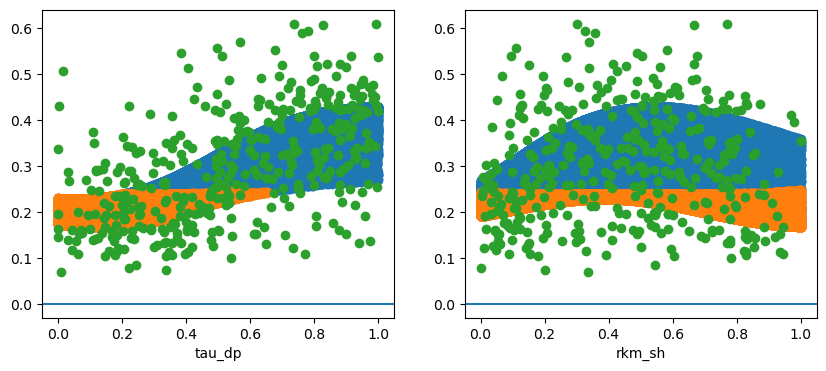

In [28]:
test_case.visualize_check('Sfc_Precip')

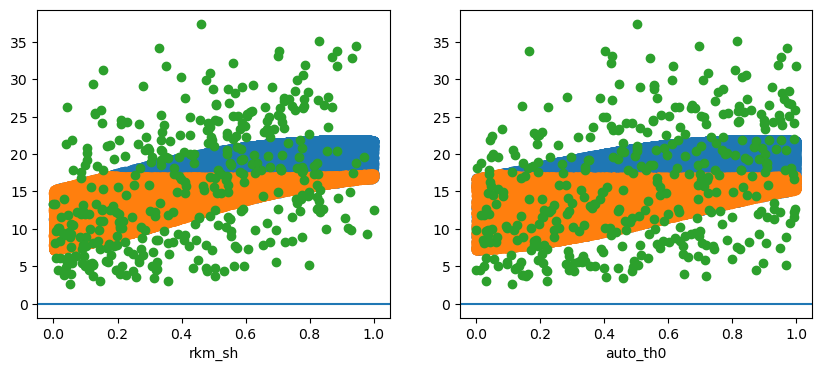

In [30]:
test_case.visualize_check('SW_TOA')

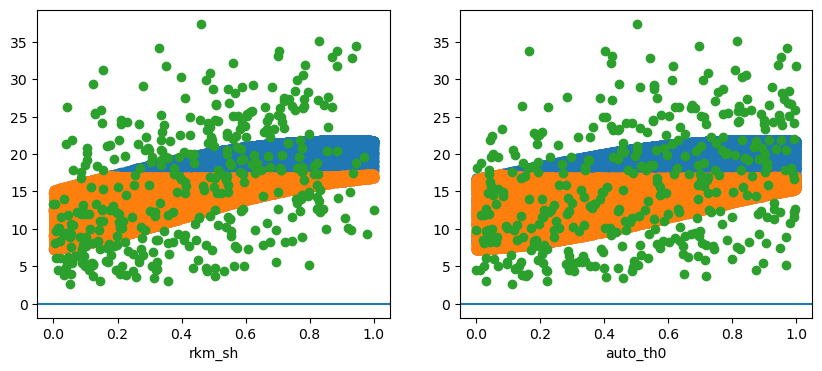

In [29]:
test_case.visualize_check('SW_TOA')

In [38]:
test_case.visualize_check('Sfc_Ocean')

FileNotFoundError: [Errno 2] No such file or directory: '/glade/work/qingyuany/gfdl_esm/v1/y_emu/gp_mean_std_Sfc_Ocean.csv'

In [40]:
test_case

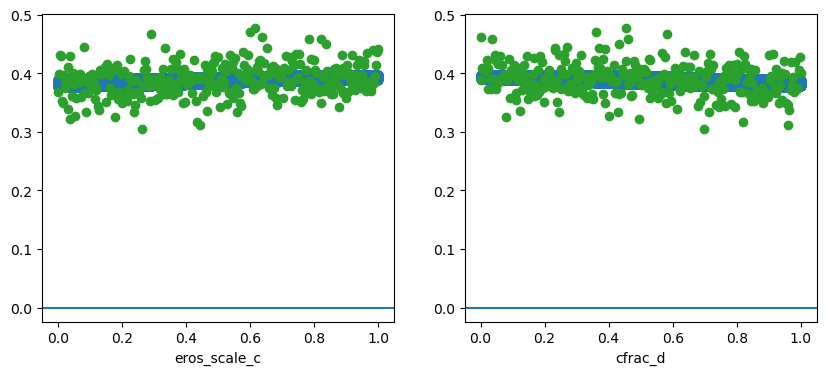

In [41]:
test_case.visualize_check('Sfc_Ocean_Winds')

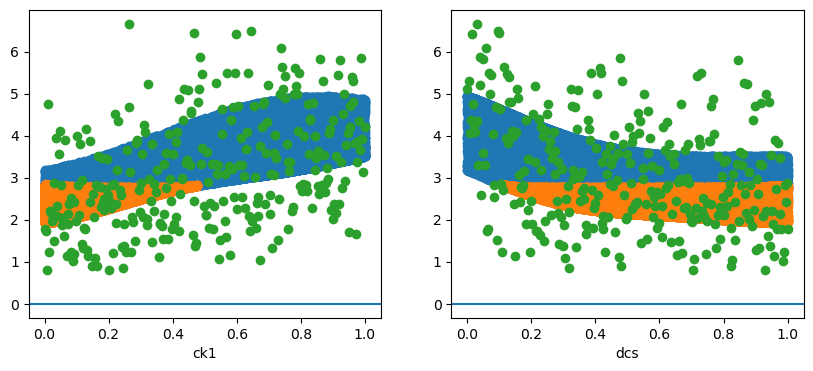

In [44]:
test_case.visualize_check('Sfc_Precip2')

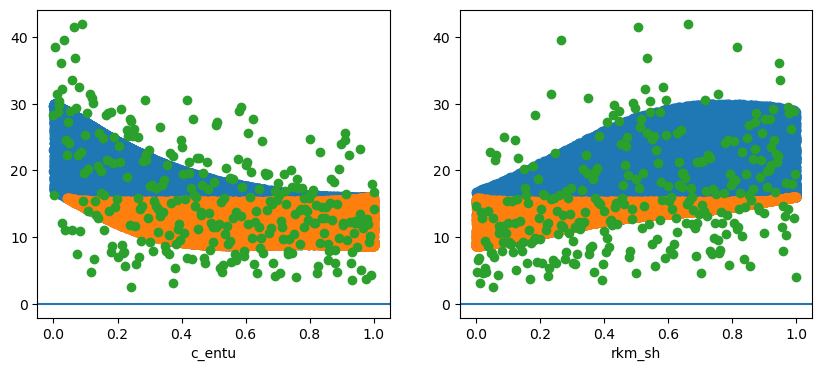

In [43]:
test_case.visualize_check('NET_TOA')

In [33]:
para = test_case.load_para_emu()
tf_masks = test_case.data_emu.tf_masks

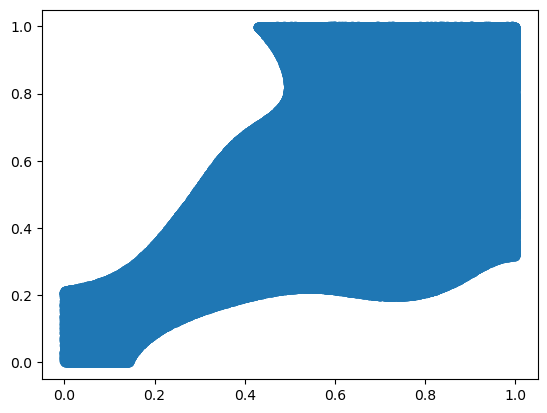

In [34]:
plt.scatter(para[tf_masks['500mb_Temperature']].IceFallFac, para[tf_masks['500mb_Temperature']].dcs)

In [105]:
obs['PRECT_-2_2_1_359']

array(5.28778056e-08)